In [1]:
import os

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from astropy.coordinates import SkyCoord
from astropy.io import fits
from gammapy.irf import load_irf_dict_from_file
from scipy.stats import chi2, poisson
from scipy.optimize import curve_fit

In [2]:
# TODO: change name if needed
name = "Mrk501"
blazar_coord = SkyCoord.from_name(name)
# TODO: change data_folder if needed
data_folder = "../cta_dc_data/mrk_501/"
data_folder_40deg = data_folder+"40deg/"
data_folder_20deg = data_folder+"20deg/"
irf_file_40deg = "../cta_dc_data/irfs/Prod5-North-40deg-AverageAz-4LSTs09MSTs.180000s-v0.1.fits.gz"
irf_file_20deg = "../cta_dc_data/irfs/Prod5-North-20deg-AverageAz-4LSTs09MSTs.180000s-v0.1.fits.gz"

In [3]:
blazar_l = blazar_coord.galactic.l.deg
blazar_b = blazar_coord.galactic.b.deg

hbus_40deg = []
hbus_20deg = []
for filename in os.listdir(data_folder_40deg):
    hbus_40deg.append(fits.open(data_folder_40deg + filename))
for filename in os.listdir(data_folder_20deg):
    hbus_20deg.append(fits.open(data_folder_20deg + filename))
    
irf_40deg = load_irf_dict_from_file(irf_file_40deg)
irf_20deg = load_irf_dict_from_file(irf_file_20deg)
print(f"Pointings 40deg: {len(hbus_40deg)}")
print(f"Pointings 20deg: {len(hbus_20deg)}")

Pointings 40deg: 60
Pointings 20deg: 66


In [4]:
e_bins=np.logspace(np.log10(0.05), np.log10(50), 16)
e_mins=e_bins[:-1]
e_maxs=e_bins[1:]
e=np.sqrt(e_mins*e_maxs)
de=e_maxs-e_mins

th2_bins=np.linspace(0,0.16,17)
th2=(th2_bins[1:]+th2_bins[:-1])/2.

**Data collecting and overview**

In [5]:
def collect_data(hbus):
    cts_s = np.zeros((len(e), len(th2)))
    cts_b = np.zeros((len(e), len(th2)))
    t_expo = 0

    for hbu in hbus:
        data_raw = hbu["EVENTS"].data
    
        t = data_raw["TIME"]
        t = np.sort(t)
        t_expo += t[-1] - t[0]
    
        coord = SkyCoord(
            ra=data_raw["RA"] * u.deg, dec=data_raw["DEC"] * u.deg, frame="icrs"
        )
    
        pointing_coord = SkyCoord(
            ra=hbu[1].header["RA_PNT"] * u.deg,
            dec=hbu[1].header["DEC_PNT"] * u.deg,
            frame="icrs",
        )
    
        bkg_center = SkyCoord(
            l=2 * pointing_coord.galactic.l - blazar_coord.galactic.l,
            b=2 * pointing_coord.galactic.b - blazar_coord.galactic.b,
            frame="galactic",
        )
        
        seps = coord.separation(blazar_coord).degree
        seps_b = coord.separation(bkg_center).degree
        src_pos_mask = seps < bkg_subtraction_radius
        bkg_pos_mask = seps_b < bkg_subtraction_radius
    
        energ = data_raw["ENERGY"]
    
        for i, (energ_min, energ_max) in enumerate(zip(e_mins, e_maxs)):
            m_s = (energ>energ_min) & (energ<energ_max) & src_pos_mask
            m_b = (energ>energ_min) & (energ<energ_max )& bkg_pos_mask
    
            h_s, _ = np.histogram(seps[m_s]**2, bins=th2_bins)
            h_b, _ = np.histogram(seps_b[m_b]**2, bins=th2_bins)
            
            cts_s[i] += h_s
            cts_b[i] += h_b
    return cts_s, cts_b, t_expo

In [6]:
bkg_subtraction_radius = 0.4

cts_s_40deg, cts_b_40deg, t_expo_40deg = collect_data(hbus_40deg)
cts_s_20deg, cts_b_20deg, t_expo_20deg = collect_data(hbus_20deg)

print(f"Exposure time 40deg = {t_expo_40deg/60/60:.1f}h")
print(f"Exposure time 20deg = {t_expo_20deg/60/60:.1f}h")

Exposure time 40deg = 8.5h
Exposure time 20deg = 9.3h


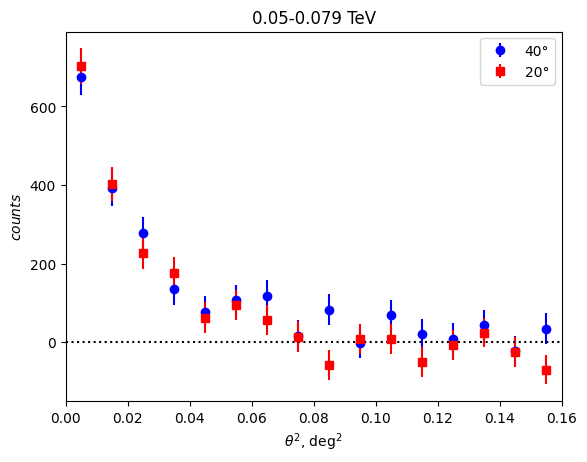

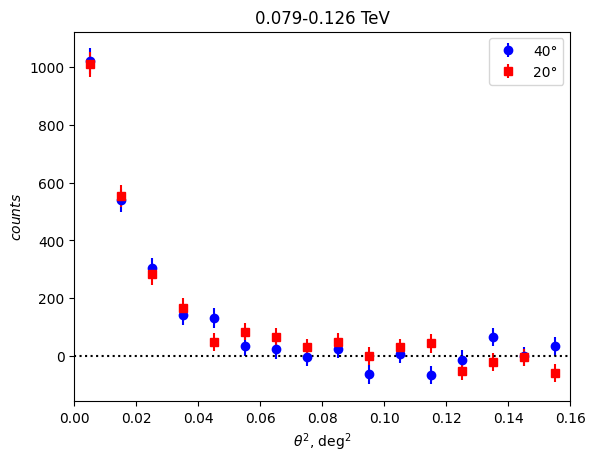

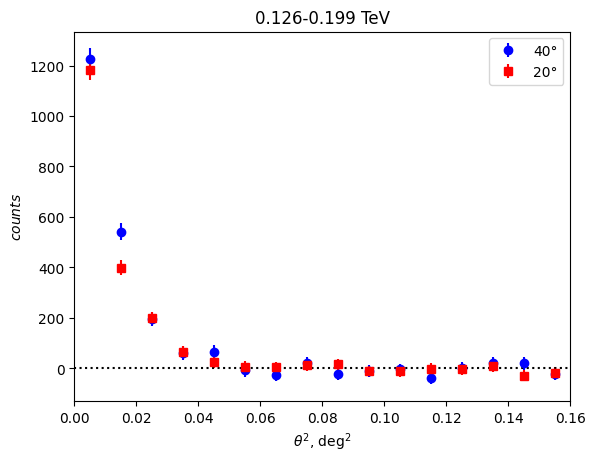

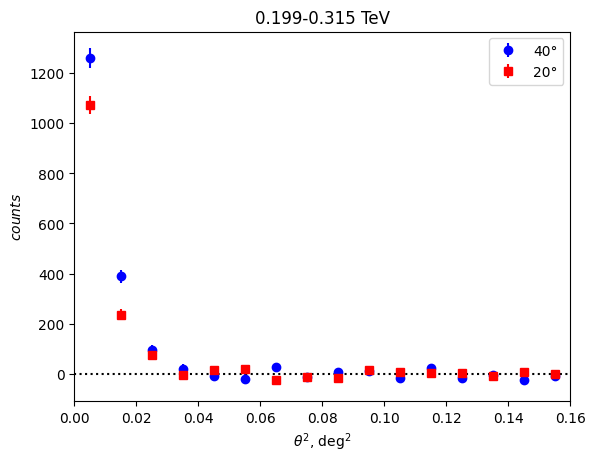

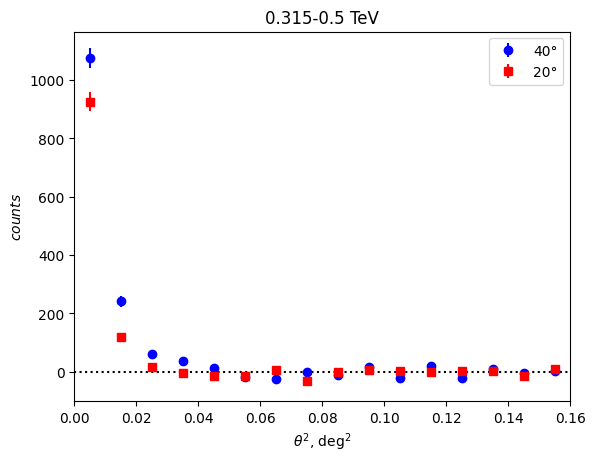

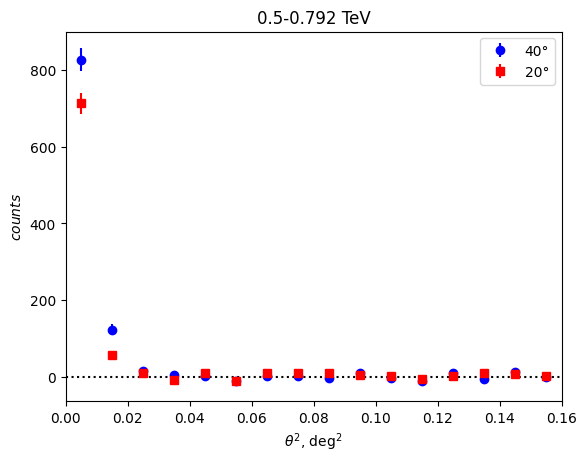

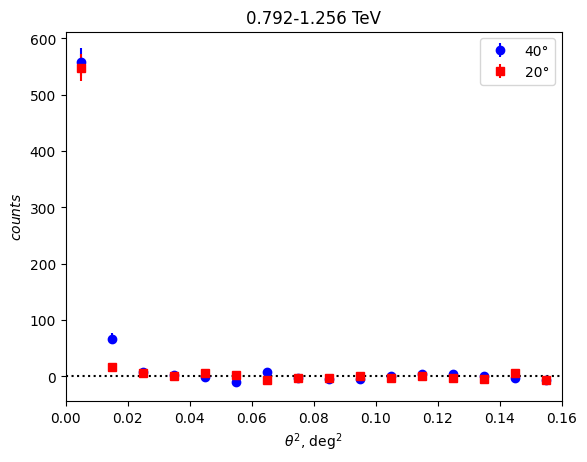

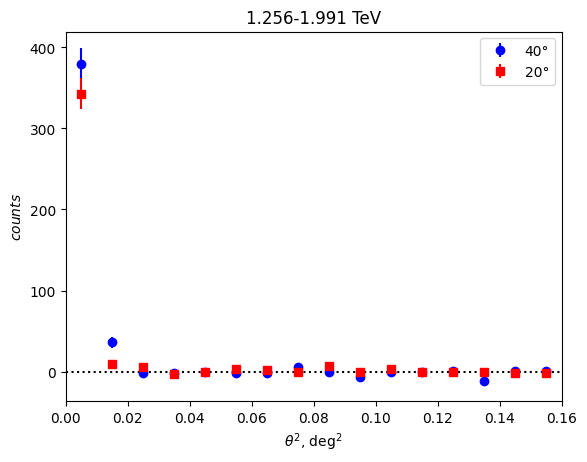

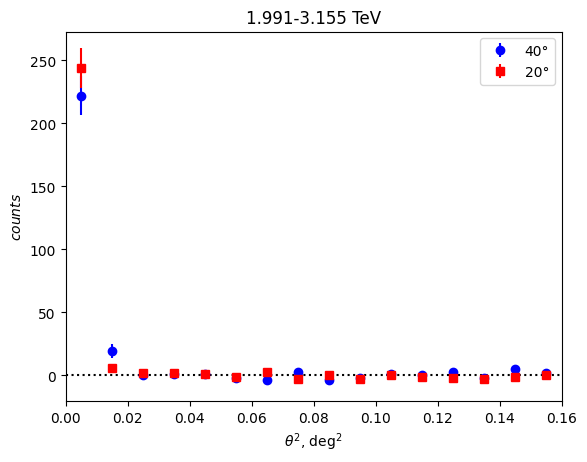

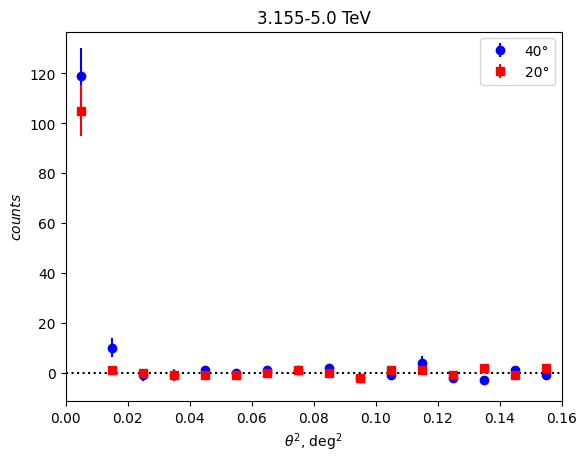

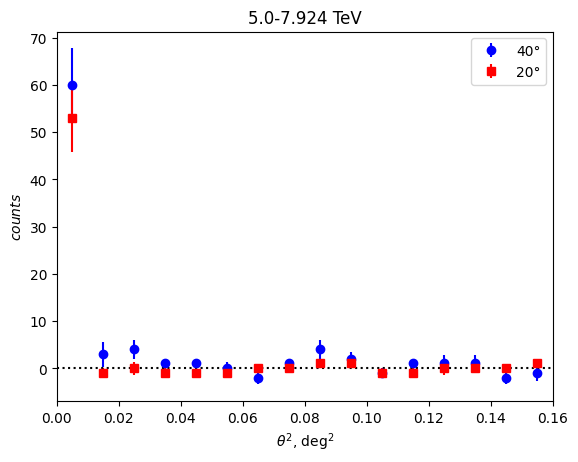

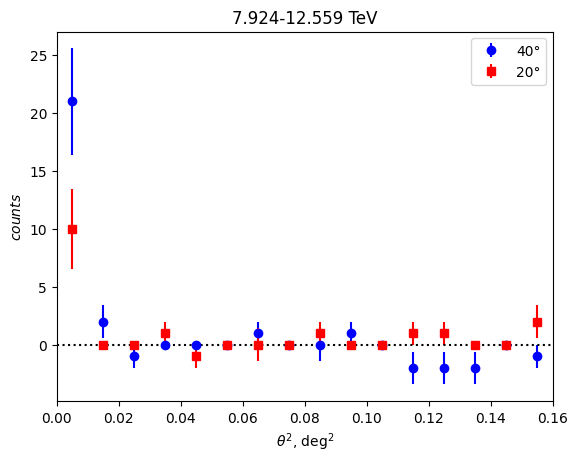

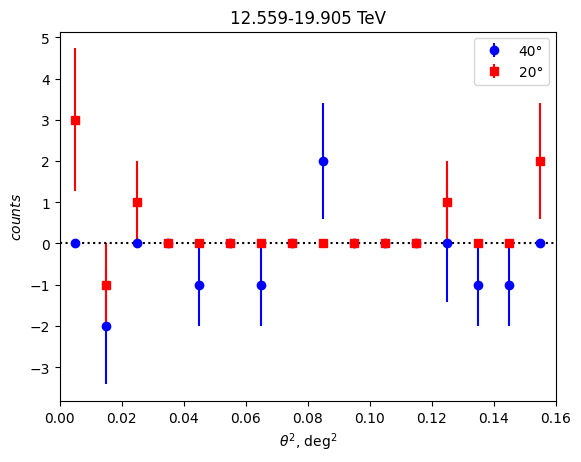

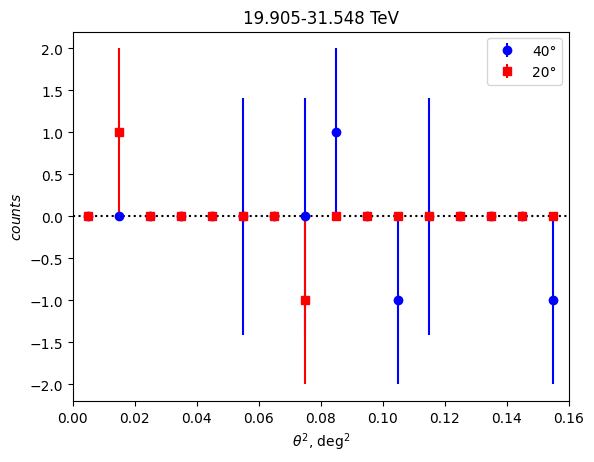

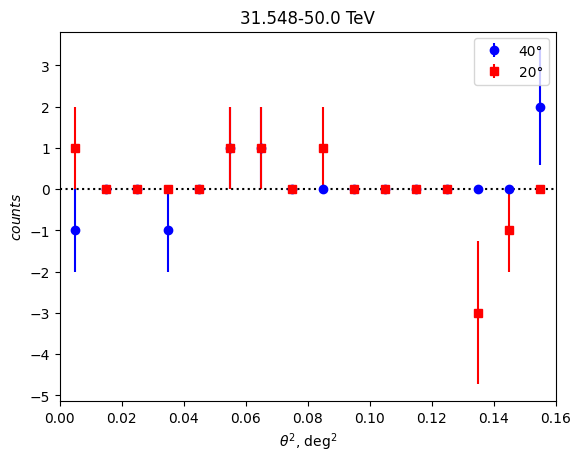

In [7]:
cts_40deg = cts_s_40deg - cts_b_40deg
cts_err_40deg = np.sqrt(cts_s_40deg + cts_b_40deg)

cts_20deg = cts_s_20deg - cts_b_20deg
cts_err_20deg = np.sqrt(cts_s_20deg + cts_b_20deg)

for i, ((cts_40, cts_err_40), (cts_20, cts_err_20)) in enumerate(zip(zip(cts_40deg, cts_err_40deg), zip(cts_20deg, cts_err_20deg))):
    plt.figure()
    plt.errorbar(th2, cts_40, cts_err_40, fmt='o', label='40°', color='blue')
    plt.errorbar(th2, cts_20, cts_err_20, fmt='s', label='20°', color='red')
    plt.axhline(0, color='black', linestyle='dotted')
    plt.xlim(0, 0.16)
    plt.title(str(round(e_mins[i],3)) + '-' + str(round(e_maxs[i],3)) + ' TeV')
    plt.xlabel(r'$\theta^2$, deg$^2$')
    plt.ylabel(r'$counts$')
    plt.legend()
    plt.show()

In [8]:
psf_hbu_40deg = irf_40deg["psf"]
psf_hbu_20deg = irf_20deg["psf"]

print(psf_hbu_40deg)
print(psf_hbu_40deg.info())
print(psf_hbu_40deg.data.shape)
# here i'm guessing the energy bins of the psf since idk how to see them.
psf_e_bins = np.logspace(np.log10(0.013), np.log10(199.526), 22)
psf_e_means = np.sqrt(psf_e_bins[1:]*psf_e_bins[:-1])
print(psf_e_bins)

EnergyDependentMultiGaussPSF
----------------------------

  axes      : ['energy_true', 'offset']
  shape     : (21, 6)
  ndim      : 2
  parameters: ['sigma_1', 'sigma_2', 'sigma_3', 'scale', 'ampl_2', 'ampl_3']


Summary PSF info
----------------
Theta          : size =     6, min =  0.500 deg, max =  5.500 deg
Energy hi      : size =    21, min =  0.020 TeV, max = 199.526 TeV
Energy lo      : size =    21, min =  0.013 TeV, max = 125.893 TeV
68.00 containment radius at offset = 0.0 deg and energy_true =  1.0 TeV: 0.074 deg
95.00 containment radius at offset = 0.0 deg and energy_true =  1.0 TeV: 0.121 deg
68.00 containment radius at offset = 0.0 deg and energy_true = 10.0 TeV: 0.062 deg
95.00 containment radius at offset = 0.0 deg and energy_true = 10.0 TeV: 0.100 deg

(21, 6)
[1.30000000e-02 2.05721347e-02 3.25548251e-02 5.15170959e-02
 8.15243565e-02 1.29010003e-01 2.04154705e-01 3.23069084e-01
 5.11247747e-01 8.09035193e-01 1.28027546e+00 2.02599994e+00
 3.20608797e+00 5.07354412

In [9]:
sigmas_ext = [0.1, 0.2, 0.3, 0.4]

In [10]:
def calculate_UL(cts, cts_err, psf_hbu):
    flux_ratios = np.zeros((len(sigmas_ext), len(e)))
    
    for i, (ct, ct_err) in enumerate(zip(cts, cts_err)):
        # psf_index will store the best index for accessing the PSF values form the file.
        psf_index = np.argmin(np.abs(psf_e_means - e[i]))
        sigma_1, sigma_2, sigma_3, scale, ampl_2, ampl_3 = psf_hbu.data[psf_index][0]
    
        # Normalization of the PSF model to fit best the blazar
        def psf_model(th2):
            gauss1 = np.exp(-th2 / (2 * sigma_1**2))
            gauss2 = ampl_2*np.exp(-th2 / (2 * sigma_2**2))
            gauss3 = ampl_3*np.exp(-th2 / (2 * sigma_3**2))
            return (gauss1+gauss2+gauss3)

        # rescaling the psf component to match total counts of the data
        psf_component = psf_model(th2)
        psf_component = sum(ct)*psf_component/sum(psf_component)
        # The errors on the counts are independent, here I used this formula for error propagation:
        # z = \sum x_i, then z_err = sqrt(\sum x_i_err**2)
        psf_component_err = np.sqrt(sum(ct_err**2))*psf_component/sum(psf_component) # THIS ERROR EXISTS IN THE FIRST PLACE???
        chi2_noext = np.sum(((ct - psf_component)**2 / (ct_err**2 + psf_component_err**2)))
    
        # taken from andrii notebook, to fit with psf better:
        step=1.01
        chi2_noext_best=1e10
        adjust=1
        while(chi2_noext<chi2_noext_best):
            chi2_noext_best=chi2_noext
            
            chisq0=sum((ct-step*adjust*psf_component)**2/(ct_err**2+(step*adjust*psf_component_err)**2))
            chisq1=sum((ct-adjust*psf_component/step)**2/(ct_err**2+(adjust*psf_component_err/step)**2))
            chisq_vec=np.array([chisq0,chisq1])
            chi2_noext=min(chisq_vec)
            ind=np.argmin(chisq_vec)
            
            if(chi2_noext<chi2_noext_best):
                if(ind==0):
                    adjust*=step
                if(ind==1):
                    adjust/=step
                    
        psf_component *= adjust
        psf_component_err *= adjust
        chi2_noext = np.sum(((ct - psf_component)**2 / (ct_err**2 + psf_component_err**2)))
        
        fig, axs = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [2, 1]})
        fig.subplots_adjust(hspace=0)
        axs[0].errorbar(th2,ct,ct_err,linestyle='none',marker='o',label=name,color='black')
        axs[0].plot(th2,psf_component,color='black',linestyle='dashed',label='PSF')
        axs[0].fill_between(th2,(psf_component-psf_component_err),(psf_component+psf_component_err),color='black',alpha=0.1,linewidth=0)
        axs[0].set_title(str(round(e[i],3))+'-'+str(round(e[i],3))+r' TeV')
        axs[1].errorbar(th2,ct - psf_component,np.sqrt(ct_err**2+psf_component_err**2),marker='o',linestyle='none',color='black')
        axs[1].axhline(0,color='black',linestyle='dashed')
    
        # For each sigma_ext: add a gaussian term norm_ext*gauss(sigma_ext) convolved with the psf, to the point source model (psf only), until delta_chi2 is > 2.71.
        # With this you found norm_ext such that the fit breaks. Lets call this norm_ext_br
        # Then the upper limit to the detectable ext. emission should be given by an extended emission of the form of: norm_ext_br*gauss(sigma_ext).
        for k, sigma_ext in enumerate(sigmas_ext):
            def ext_model(th2):
                sigma1_conv = np.sqrt(sigma_1**2 + sigma_ext**2)
                sigma2_conv = np.sqrt(sigma_2**2 + sigma_ext**2)
                sigma3_conv = np.sqrt(sigma_3**2 + sigma_ext**2)
                gauss1_conv = np.exp(-th2 / (2 * sigma1_conv**2))
                gauss2_conv = ampl_2 * np.exp(-th2 / (2 * sigma2_conv**2))
                gauss3_conv = ampl_3 * np.exp(-th2 / (2 * sigma3_conv**2))
                return gauss1_conv + gauss2_conv + gauss3_conv
        
            ct_ext = ext_model(th2)
            ct_ext = sum(ct)*ct_ext/sum(ct_ext)
            ct_ext_plus_src = ct_ext+psf_component
            chi2_ext = np.sum(((ct - ct_ext_plus_src)**2 / (ct_err**2 + psf_component_err**2)))

            # Finding the best fit for psf*(extended + point)
            step=1.01
            chi2_ext_best = 1e10
            adjust_ext = 1
            adjust_point = 1
            while(chi2_ext < chi2_ext_best):
                chi2_ext_best = chi2_ext
                #ct_ext_err*=adjust_ext for the moment without error
                
                chisq0=sum((ct-step*adjust_point*psf_component-adjust_ext*ct_ext)**2/(ct_err**2+(step*adjust_point*psf_component_err)**2))
                chisq1=sum((ct-adjust_point*psf_component/step-adjust_ext*ct_ext)**2/(ct_err**2+(adjust_point*psf_component_err/step)**2))
                chisq2=sum((ct-adjust_point*psf_component-step*adjust_ext*ct_ext)**2/(ct_err**2+adjust_point*psf_component_err**2))
                chisq3=sum((ct-adjust_point*psf_component-adjust_ext*ct_ext/step)**2/(ct_err**2+adjust_point*psf_component_err**2))
                chisq_vec=np.array([chisq0,chisq1,chisq2,chisq3])
                chi2_ext=min(chisq_vec)
                ind=np.argmin(chisq_vec)
                
                if(chi2_ext<chi2_ext_best):
                    if(ind==0):
                        adjust_point*=step
                    if(ind==1):
                        adjust_point/=step
                    if(ind==2):
                        adjust_ext*=step
                    if(ind==3):
                        adjust_ext/=step

            ct_ext*=adjust_ext
            psf_component*=adjust_point
            psf_component_err*=adjust_point
            
            cts_tot_best = np.sum(ct_ext_plus_src)
            chi2_ext = np.sum(((ct - ct_ext - psf_component)**2 / (ct_err**2 + psf_component_err**2)))
            
            chi2_ext_best = chi2_ext
            ct_ext_best = ct_ext
            print(f"Best fit extended plus point gives chi2: {chi2_ext}")

            # Upper limits
            step=1.01
            chi2_ext_best = chi2_ext
            adjust_ext = 1
            adjust_point = 1
            while(chi2_ext < chi2_ext_best + 2.71):
                adjust_ext *= step
                ct_ext = ct_ext_best*adjust_ext
                chi2_ext = np.sum(((ct - psf_component - ct_ext)**2 / (ct_err**2 + psf_component_err**2)))

                chi2_ext_best_fixed_ext = 1e10
                while(chi2_ext < chi2_ext_best_fixed_ext):
                    chi2_ext_best_fixed_ext = chi2_ext
                    
                    chisq0=sum((ct-step*adjust_point*psf_component-ct_ext)**2/(ct_err**2+(step*adjust_point*psf_component_err)**2))
                    chisq1=sum((ct-adjust_point*psf_component/step-ct_ext)**2/(ct_err**2+(adjust_point*psf_component_err/step)**2))
                    chisq_vec=np.array([chisq0,chisq1])
                    chi2_ext=min(chisq_vec)
                    ind=np.argmin(chisq_vec)
                    
                    if(chi2_ext<chi2_ext_best_fixed_ext):
                        if(ind==0):
                            adjust_point*=step
                        if(ind==1):
                            adjust_point/=step

            flux_ratio = np.sum(ct_ext)/cts_tot_best
            flux_ratios[k][i] = flux_ratio
            axs[0].plot(th2,ct_ext,color='blue',alpha=0.5,linestyle='dashdot',label='extended source U.L.')
            
        plt.xlabel(r'$\theta^2$, deg$^2$')
        axs[0].set_ylabel('Counts')
        axs[0].legend()
        axs[0].set_yscale('log')
        plt.show()
    return flux_ratios

Best fit extended plus point gives chi2: 12.378896047049727
Best fit extended plus point gives chi2: 11.506192221556455
Best fit extended plus point gives chi2: 10.85909307571222
Best fit extended plus point gives chi2: 10.553000605367316


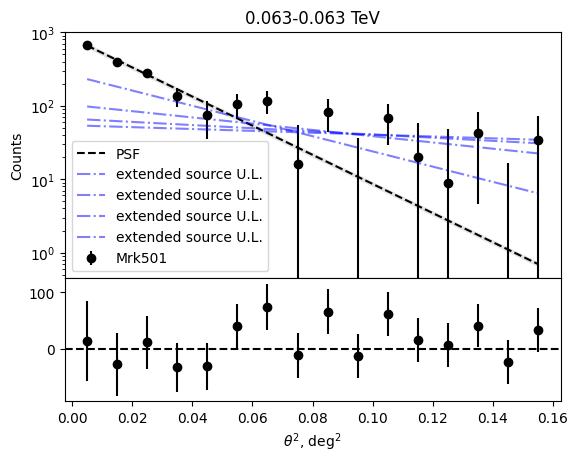

Best fit extended plus point gives chi2: 17.002869788645178
Best fit extended plus point gives chi2: 17.044513516645388
Best fit extended plus point gives chi2: 17.06529728162999
Best fit extended plus point gives chi2: 17.00350424038387


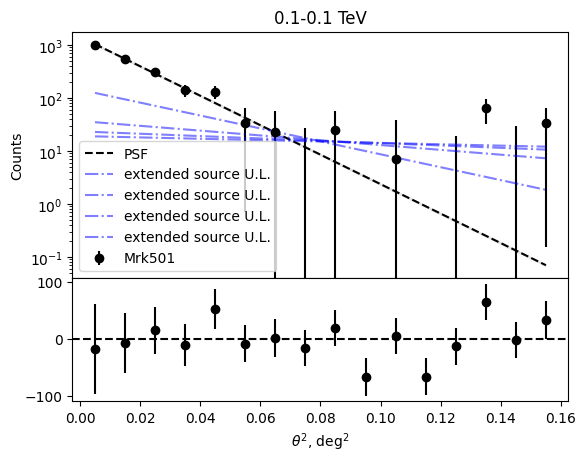

Best fit extended plus point gives chi2: 13.277101244816798
Best fit extended plus point gives chi2: 13.277101244816699
Best fit extended plus point gives chi2: 13.277101244816713
Best fit extended plus point gives chi2: 13.277101244816816


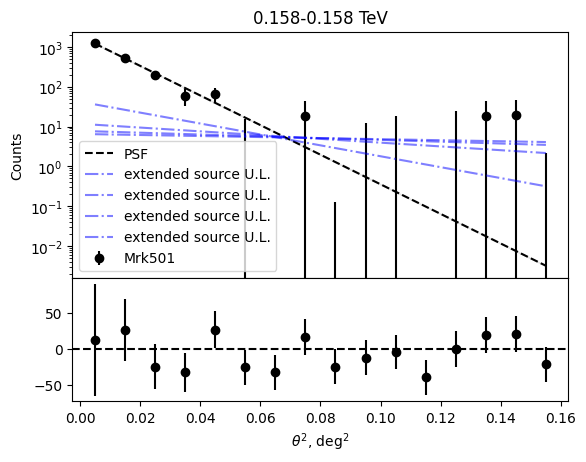

Best fit extended plus point gives chi2: 14.051694403255754
Best fit extended plus point gives chi2: 14.051694403256043
Best fit extended plus point gives chi2: 14.051694403256086
Best fit extended plus point gives chi2: 14.051694403256029


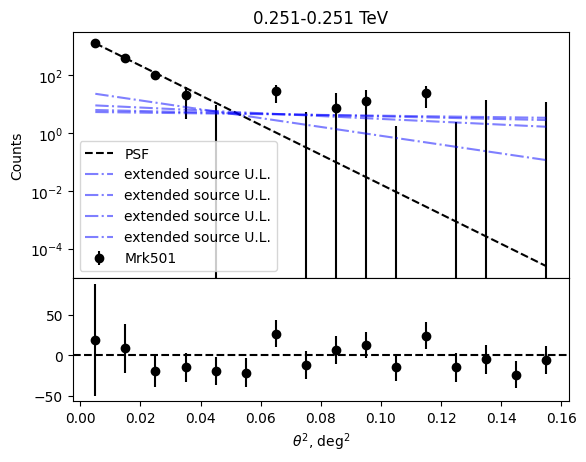

Best fit extended plus point gives chi2: 26.446805964769126
Best fit extended plus point gives chi2: 27.05220452288002
Best fit extended plus point gives chi2: 27.05220452288017
Best fit extended plus point gives chi2: 27.05220452287994


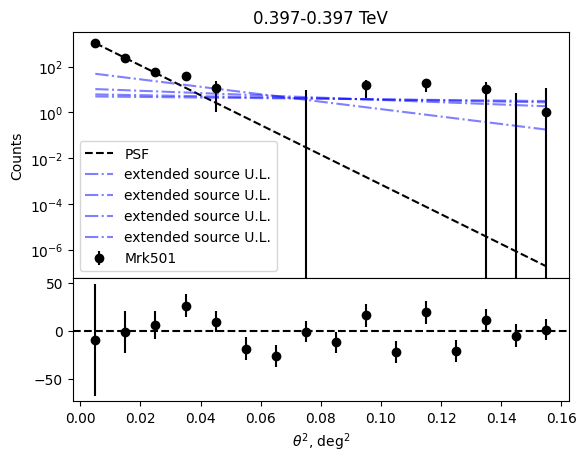

Best fit extended plus point gives chi2: 15.155046066293078
Best fit extended plus point gives chi2: 15.155046066293139
Best fit extended plus point gives chi2: 15.155046066293089
Best fit extended plus point gives chi2: 15.155046066293211


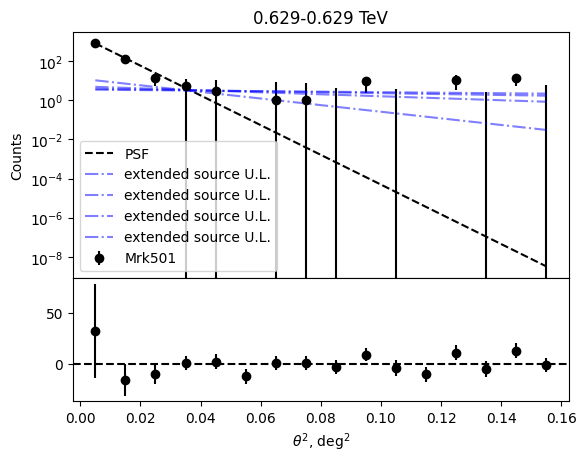

Best fit extended plus point gives chi2: 11.013871466055692
Best fit extended plus point gives chi2: 11.013871466056003
Best fit extended plus point gives chi2: 11.013871466055878
Best fit extended plus point gives chi2: 11.013871466056155


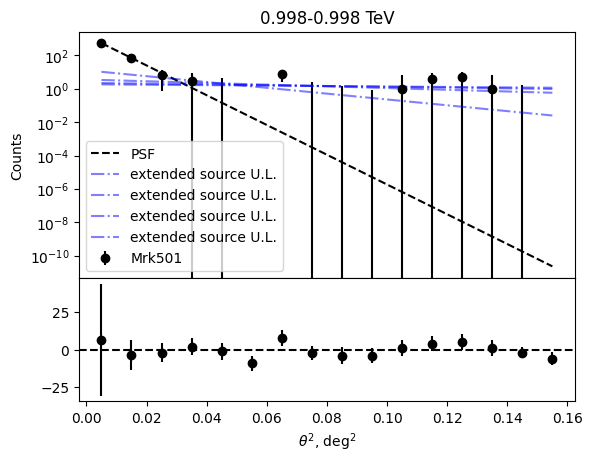

Best fit extended plus point gives chi2: 19.789729551486534
Best fit extended plus point gives chi2: 19.78972955148664
Best fit extended plus point gives chi2: 19.789729551486452
Best fit extended plus point gives chi2: 19.789729551486552


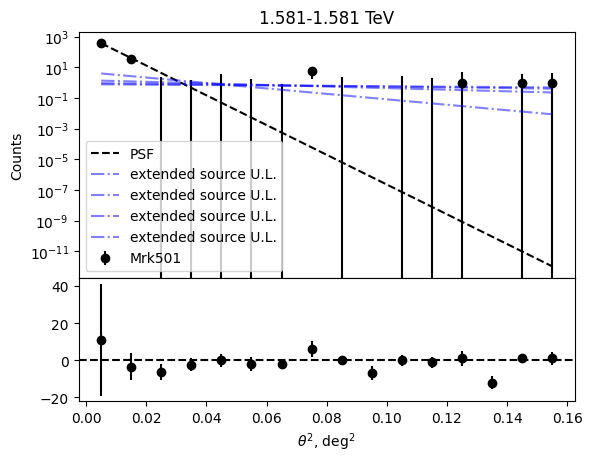

Best fit extended plus point gives chi2: 14.757219067701005
Best fit extended plus point gives chi2: 14.736707261278596
Best fit extended plus point gives chi2: 14.664791601494834
Best fit extended plus point gives chi2: 14.60846145789209


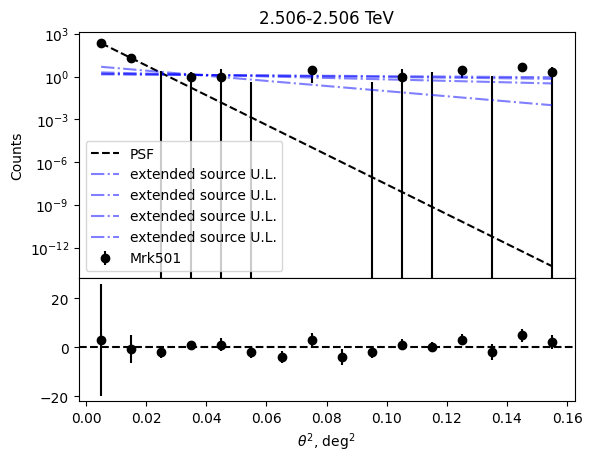

Best fit extended plus point gives chi2: 13247912091.698332
Best fit extended plus point gives chi2: 38740538606.433655
Best fit extended plus point gives chi2: 35287378299.44797
Best fit extended plus point gives chi2: 32729940932.08457


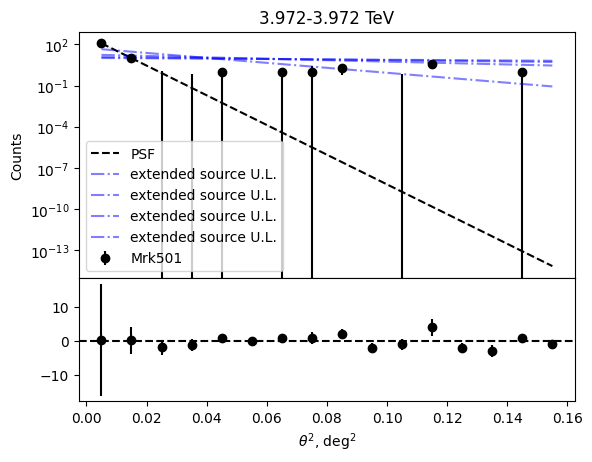

Best fit extended plus point gives chi2: 16.63620841762092
Best fit extended plus point gives chi2: 16.365703875836374
Best fit extended plus point gives chi2: 16.894610441341946
Best fit extended plus point gives chi2: 17.18117433567868


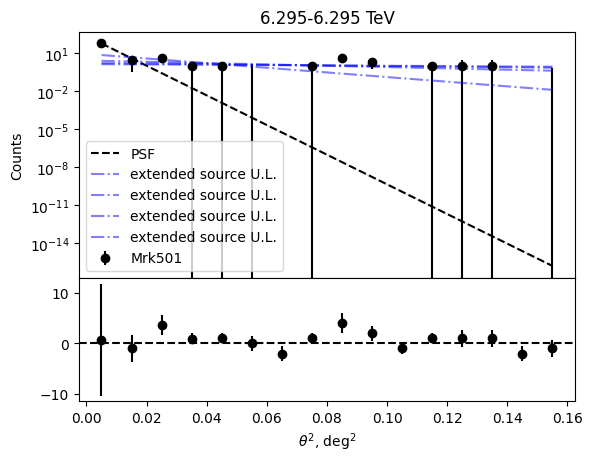

Best fit extended plus point gives chi2: 2.0799722429947804e+33
Best fit extended plus point gives chi2: 1.847034815753283e+36
Best fit extended plus point gives chi2: 5.490410416735772e+36
Best fit extended plus point gives chi2: 7.792900079654685e+36


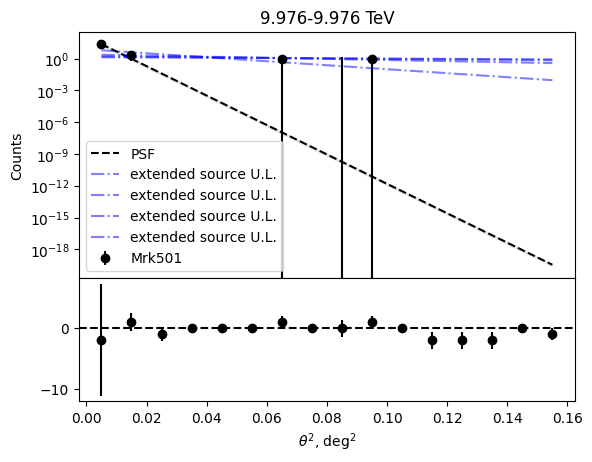

Best fit extended plus point gives chi2: 5.074320719914712e+42
Best fit extended plus point gives chi2: 1.136108682320205e+46
Best fit extended plus point gives chi2: 3.909226923875884e+46
Best fit extended plus point gives chi2: 5.830699407098952e+46


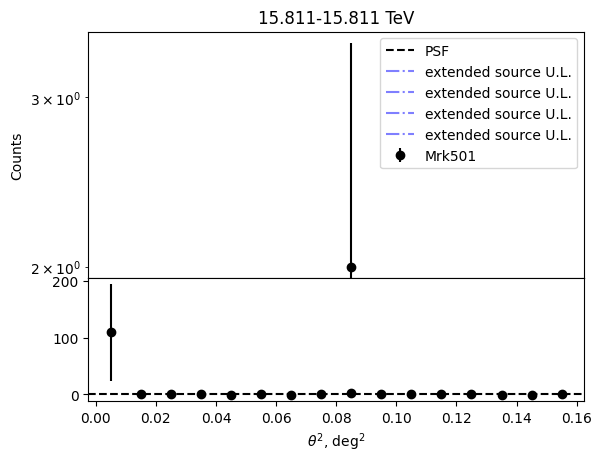

Best fit extended plus point gives chi2: 2.965761765722123e+48
Best fit extended plus point gives chi2: 4.0414295816251266e+51
Best fit extended plus point gives chi2: 1.2262037839742577e+52
Best fit extended plus point gives chi2: 1.7457501093843424e+52


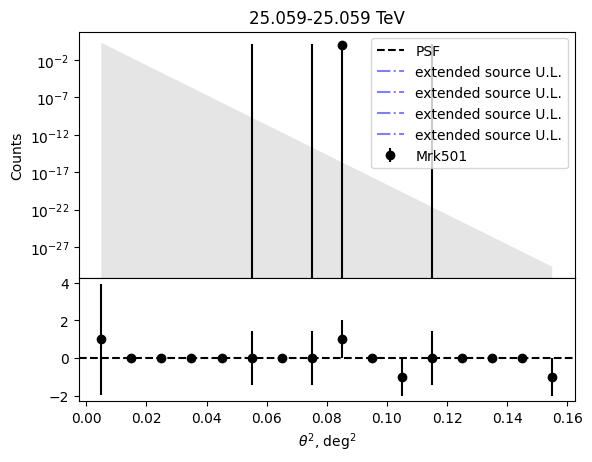

Best fit extended plus point gives chi2: 2.433135397798321e+59
Best fit extended plus point gives chi2: 4.258519101548171e+62
Best fit extended plus point gives chi2: 1.3068667908241988e+63
Best fit extended plus point gives chi2: 1.863718303672568e+63


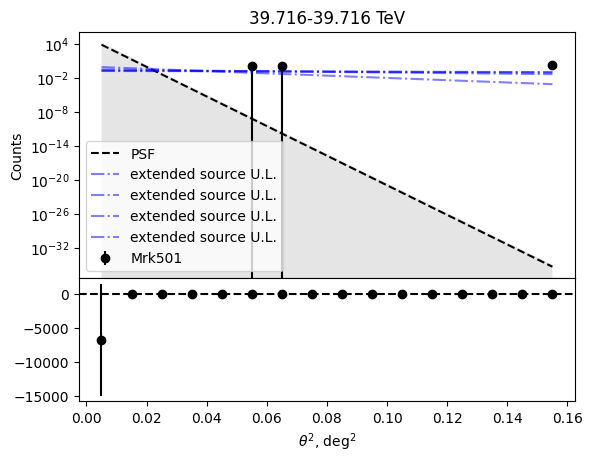

Best fit extended plus point gives chi2: 18.388303422799705
Best fit extended plus point gives chi2: 21.841725337804903
Best fit extended plus point gives chi2: 20.423155674591264
Best fit extended plus point gives chi2: 18.661923083790477


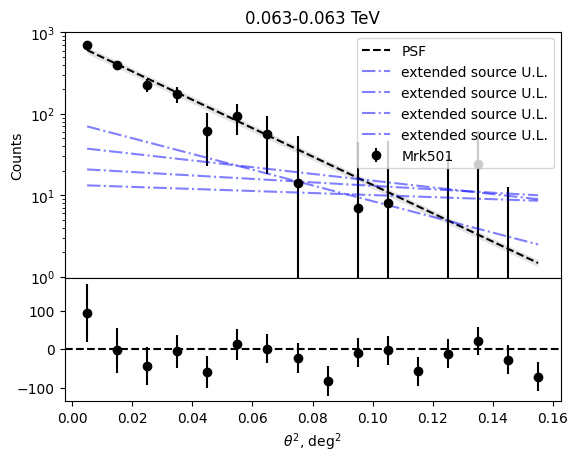

Best fit extended plus point gives chi2: 16.375572331995674
Best fit extended plus point gives chi2: 16.725639689239802
Best fit extended plus point gives chi2: 17.2468089886375
Best fit extended plus point gives chi2: 17.481244569167952


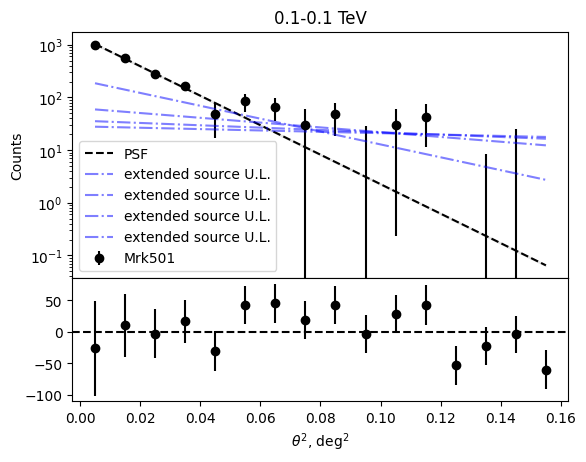

Best fit extended plus point gives chi2: 7.022653512812817
Best fit extended plus point gives chi2: 7.7529438889809335
Best fit extended plus point gives chi2: 7.760996622831769
Best fit extended plus point gives chi2: 7.342207676528572


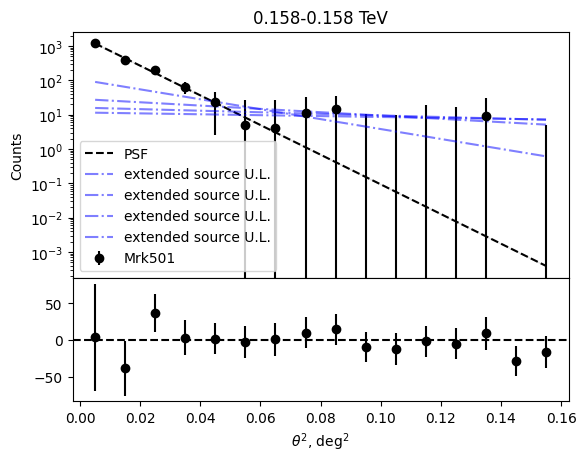

Best fit extended plus point gives chi2: 12.294987895121348
Best fit extended plus point gives chi2: 12.585424800093481
Best fit extended plus point gives chi2: 12.628173832803892
Best fit extended plus point gives chi2: 12.640601647800636


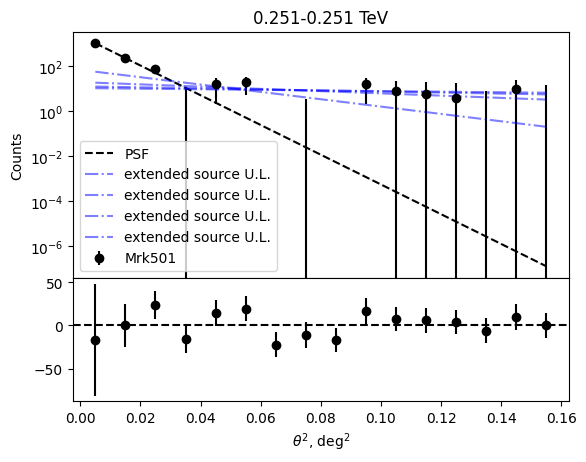

Best fit extended plus point gives chi2: 19.78523742571658
Best fit extended plus point gives chi2: 19.78523742571665
Best fit extended plus point gives chi2: 19.785237425716684
Best fit extended plus point gives chi2: 19.785237425716804


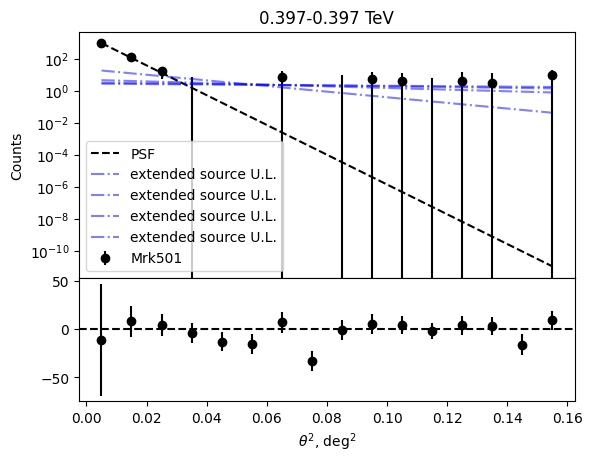

Best fit extended plus point gives chi2: 20.677094901546244
Best fit extended plus point gives chi2: 19.216861836855855
Best fit extended plus point gives chi2: 18.53520819229578
Best fit extended plus point gives chi2: 18.34422333216529


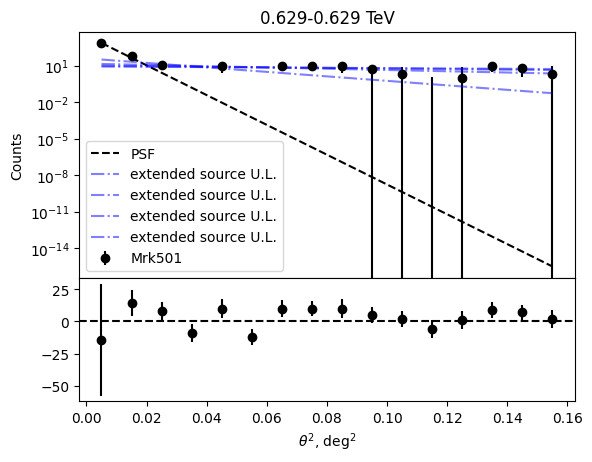

Best fit extended plus point gives chi2: 10.299412178791528
Best fit extended plus point gives chi2: 11.118185210256465
Best fit extended plus point gives chi2: 11.472166959126668
Best fit extended plus point gives chi2: 11.548166368794535


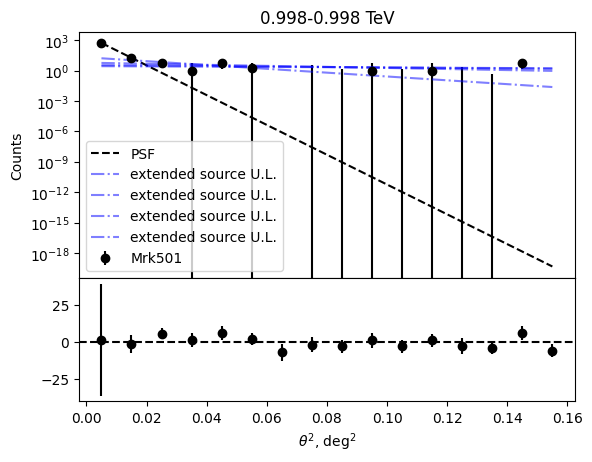

Best fit extended plus point gives chi2: 11.238967326290595
Best fit extended plus point gives chi2: 11.088928875454986
Best fit extended plus point gives chi2: 11.484727719313124
Best fit extended plus point gives chi2: 11.686519360606823


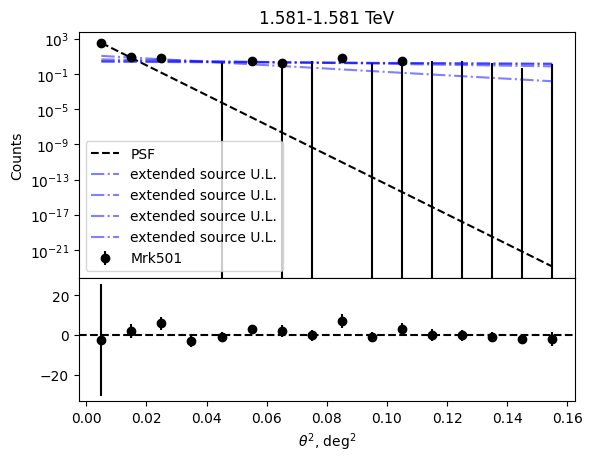

Best fit extended plus point gives chi2: 14.4744358048305
Best fit extended plus point gives chi2: 17.760956404877856
Best fit extended plus point gives chi2: 18.17676640680535
Best fit extended plus point gives chi2: 18.17676640680548


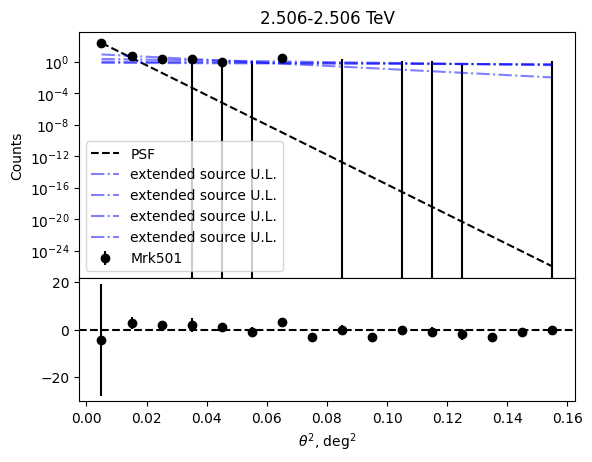

Best fit extended plus point gives chi2: 6.547839815222009e+22
Best fit extended plus point gives chi2: 4.6194370501612676e+23
Best fit extended plus point gives chi2: 4.814158181361022e+23
Best fit extended plus point gives chi2: 4.67950197957052e+23


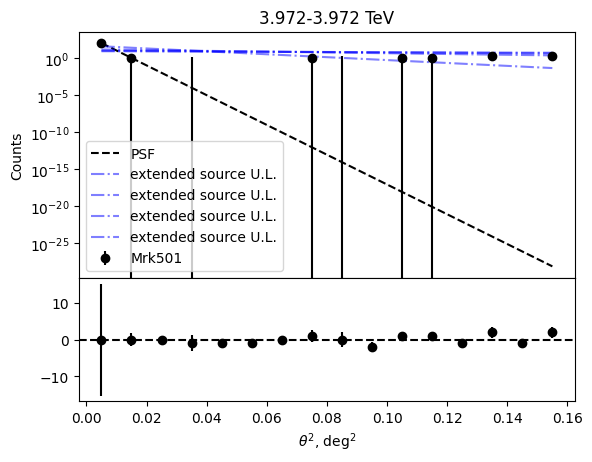

Best fit extended plus point gives chi2: 2.0855113275869614e+60
Best fit extended plus point gives chi2: 3.306091007566568e+63
Best fit extended plus point gives chi2: 1.010077458643336e+64
Best fit extended plus point gives chi2: 1.4395259579268086e+64


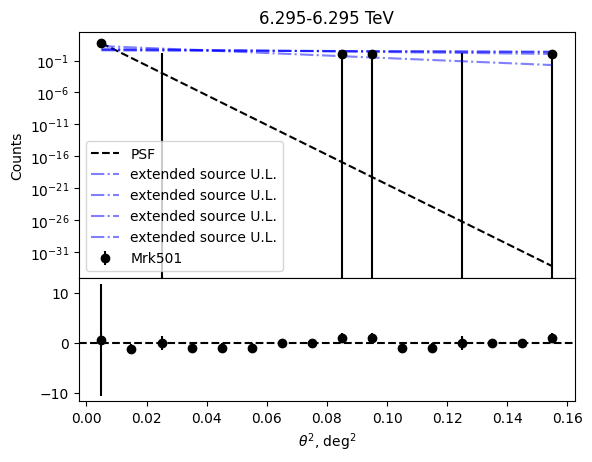

Best fit extended plus point gives chi2: 1.150689321066328e+79
Best fit extended plus point gives chi2: 2.2493180544010747e+82
Best fit extended plus point gives chi2: 6.93662379967465e+82
Best fit extended plus point gives chi2: 9.899383555460294e+82


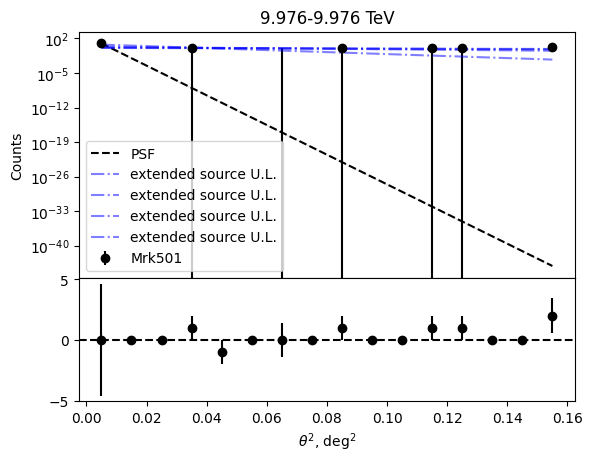

Best fit extended plus point gives chi2: 1.1496363654952397e+105
Best fit extended plus point gives chi2: 2.684283343555561e+108
Best fit extended plus point gives chi2: 8.342005959263486e+108
Best fit extended plus point gives chi2: 1.1918397138769436e+109


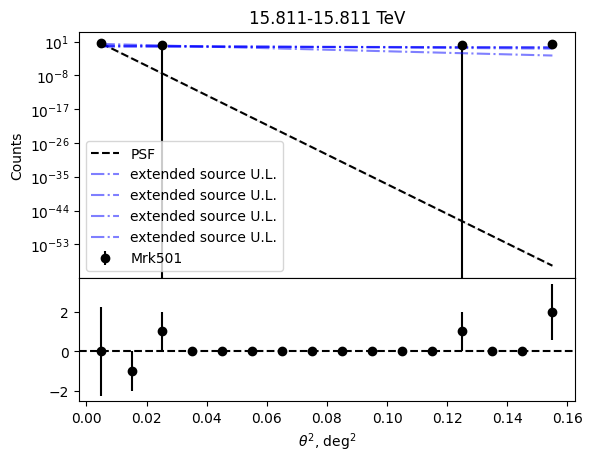

/tmp/ipykernel_4411/3678643077.py:21: RuntimeWarning: invalid value encountered in divide
  psf_component_err = np.sqrt(sum(ct_err**2))*psf_component/sum(psf_component) # THIS ERROR EXISTS IN THE FIRST PLACE???
/tmp/ipykernel_4411/3678643077.py:138: RuntimeWarning: invalid value encountered in scalar divide
  flux_ratio = np.sum(ct_ext)/cts_tot_best


Best fit extended plus point gives chi2: nan
Best fit extended plus point gives chi2: nan
Best fit extended plus point gives chi2: nan
Best fit extended plus point gives chi2: nan


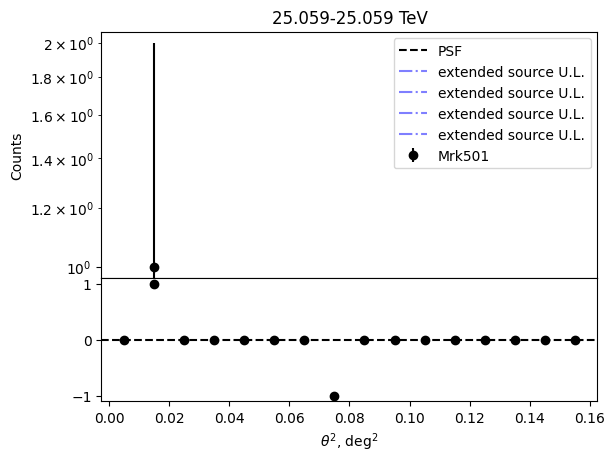

Best fit extended plus point gives chi2: nan
Best fit extended plus point gives chi2: nan
Best fit extended plus point gives chi2: nan
Best fit extended plus point gives chi2: nan


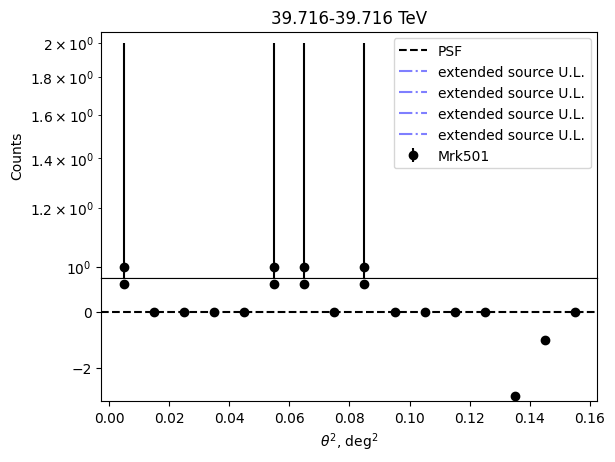

In [11]:
flux_ratios_40deg = calculate_UL(cts_40deg, cts_err_40deg, psf_hbu_40deg)
flux_ratios_20deg = calculate_UL(cts_20deg, cts_err_20deg, psf_hbu_20deg)

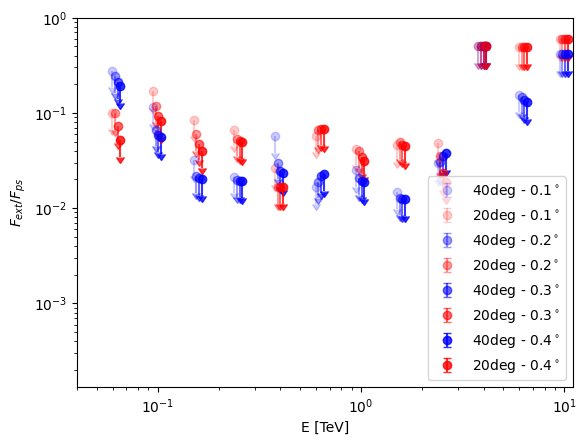

In [12]:
for i, (flux_ratio_40deg, flux_ratio_20deg) in enumerate(zip(flux_ratios_40deg, flux_ratios_20deg)):
    plt.errorbar(e*(0.95*1.03**i), flux_ratio_40deg,flux_ratio_40deg/3, alpha=0.2+0.2*i, uplims=True, linestyle='none',marker='o', label="40deg - "+str(round(sigmas_ext[i],3))+r'$^\circ$',color='blue')
    plt.errorbar(e*(0.95*1.03**i), flux_ratio_20deg,flux_ratio_20deg/3, alpha=0.2+0.2*i, uplims=True, linestyle='none',marker='o', label="20deg - "+str(round(sigmas_ext[i],3))+r'$^\circ$',color='red')
plt.xscale("log")
plt.yscale("log")
plt.ylabel(r"$F_{ext}/F_{ps}$")
plt.xlabel("E [TeV]")
plt.xlim(0.04,11)
plt.legend()

In [24]:
def calculate_UL_merged(cts_40deg, cts_err_40deg, psf_hbu_40deg, cts_20deg, cts_err_20deg, psf_hbu_20deg):
    flux_ratios = np.zeros((len(sigmas_ext), len(e)))
    th2_extended = np.concatenate([th2, th2])
    
    for i, ((ct_40deg, ct_err_40deg), (ct_20deg, ct_err_20deg)) in enumerate(zip(zip(cts_40deg, cts_err_40deg), zip(cts_20deg, cts_err_20deg))):
        ct = np.concatenate([ct_40deg, ct_20deg])
        ct_err = np.concatenate([ct_err_40deg, ct_err_20deg])
        # psf_index will store the best index for accessing the PSF values form the file.
        psf_index = np.argmin(np.abs(psf_e_means - e[i]))
        sigma_1_40deg, sigma_2_40deg, sigma_3_40deg, scale_40deg, ampl_2_40deg, ampl_3_40deg = psf_hbu_40deg.data[psf_index][0]
        sigma_1_20deg, sigma_2_20deg, sigma_3_20deg, scale_20deg, ampl_2_20deg, ampl_3_20deg = psf_hbu_20deg.data[psf_index][0]
        
        # Normalization of the PSF model to fit best the blazar
        def psf_model_40deg(th2):
            gauss1 = np.exp(-th2 / (2 * sigma_1_40deg**2))
            gauss2 = ampl_2_40deg * np.exp(-th2 / (2 * sigma_2_40deg**2))
            gauss3 = ampl_3_40deg * np.exp(-th2 / (2 * sigma_3_40deg**2))
            return scale_40deg*(gauss1 + gauss2 + gauss3)
         
        def psf_model_20deg(th2):
            gauss1 = np.exp(-th2 / (2 * sigma_1_20deg**2))
            gauss2 = ampl_2_20deg * np.exp(-th2 / (2 * sigma_2_20deg**2))
            gauss3 = ampl_3_20deg * np.exp(-th2 / (2 * sigma_3_20deg**2))
            return scale_20deg*(gauss1 + gauss2 + gauss3)

        psf_component_40deg = psf_model_40deg(th2)
        psf_component_20deg = psf_model_20deg(th2)
        psf_component = np.concatenate([psf_component_40deg, psf_component_20deg])

        # CHANGES FINISH FOR A WHILE
        
        # rescaling the psf component to match total counts of the data
        psf_component = sum(ct)*psf_component/sum(psf_component)
        # The errors on the counts are independent, here I used this formula for error propagation:
        # z = \sum x_i, then z_err = sqrt(\sum x_i_err**2)
        psf_component_err = np.sqrt(sum(ct_err**2))*psf_component/sum(psf_component) # THIS ERROR EXISTS IN THE FIRST PLACE???
        chi2_noext = np.sum(((ct - psf_component)**2 / (ct_err**2 + psf_component_err**2)))
    
        # taken from andrii notebook, to fit with psf better:
        step=1.01
        chi2_noext_best=1e10
        adjust=1
        while(chi2_noext<chi2_noext_best):
            chi2_noext_best=chi2_noext
            
            chisq0=sum((ct-step*adjust*psf_component)**2/(ct_err**2+(step*adjust*psf_component_err)**2))
            chisq1=sum((ct-adjust*psf_component/step)**2/(ct_err**2+(adjust*psf_component_err/step)**2))
            chisq_vec=np.array([chisq0,chisq1])
            chi2_noext=min(chisq_vec)
            ind=np.argmin(chisq_vec)
            
            if(chi2_noext<chi2_noext_best):
                if(ind==0):
                    adjust*=step
                if(ind==1):
                    adjust/=step
                    
        psf_component *= adjust
        psf_component_err *= adjust
        chi2_noext = np.sum(((ct - psf_component)**2 / (ct_err**2 + psf_component_err**2)))

        fig, axs = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [2, 1]})
        fig.subplots_adjust(hspace=0)
        axs[0].errorbar(th2_extended,ct,ct_err,linestyle='none',marker='o',label=name,color='black')
        axs[0].plot(th2_extended,psf_component,color='black',linestyle='dashed',label='PSF')
        axs[0].fill_between(th2_extended,(psf_component-psf_component_err),(psf_component+psf_component_err),color='black',alpha=0.1,linewidth=0)
        axs[0].set_title(str(round(e[i],3))+'-'+str(round(e[i],3))+r' TeV')
        axs[1].errorbar(th2_extended,ct - psf_component,np.sqrt(ct_err**2+psf_component_err**2),marker='o',linestyle='none',color='black')
        axs[1].axhline(0,color='black',linestyle='dashed')
    
        # For each sigma_ext: add a gaussian term norm_ext*gauss(sigma_ext) convolved with the psf, to the point source model (psf only), until delta_chi2 is > 2.71.
        # With this you found norm_ext such that the fit breaks. Lets call this norm_ext_br
        # Then the upper limit to the detectable ext. emission should be given by an extended emission of the form of: norm_ext_br*gauss(sigma_ext).
        for k, sigma_ext in enumerate(sigmas_ext):
            # CHANGES CONTINUE
            def ext_model_40deg(th2):
                sigma1_conv = np.sqrt(sigma_1_40deg**2 + sigma_ext**2)
                sigma2_conv = np.sqrt(sigma_2_40deg**2 + sigma_ext**2)
                sigma3_conv = np.sqrt(sigma_3_40deg**2 + sigma_ext**2)
                gauss1_conv = np.exp(-th2 / (2 * sigma1_conv**2))
                gauss2_conv = ampl_2_40deg * np.exp(-th2 / (2 * sigma2_conv**2))
                gauss3_conv = ampl_3_40deg * np.exp(-th2 / (2 * sigma3_conv**2))
                return scale_40deg*(gauss1_conv + gauss2_conv + gauss3_conv)

            def ext_model_20deg(th2):
                sigma1_conv = np.sqrt(sigma_1_20deg**2 + sigma_ext**2)
                sigma2_conv = np.sqrt(sigma_2_20deg**2 + sigma_ext**2)
                sigma3_conv = np.sqrt(sigma_3_20deg**2 + sigma_ext**2)
                gauss1_conv = np.exp(-th2 / (2 * sigma1_conv**2))
                gauss2_conv = ampl_2_20deg * np.exp(-th2 / (2 * sigma2_conv**2))
                gauss3_conv = ampl_3_20deg * np.exp(-th2 / (2 * sigma3_conv**2))
                return scale_20deg*(gauss1_conv + gauss2_conv + gauss3_conv)

            ct_ext_40deg = ext_model_40deg(th2)
            ct_ext_20deg = ext_model_20deg(th2)
            
            ct_ext = np.concatenate([ext_model_40deg, ext_model_20deg])
            ct_ext = sum(ct)*ct_ext/sum(ct_ext)
            ct_ext_plus_src = ct_ext+psf_component
            chi2_ext = np.sum(((ct - ct_ext_plus_src)**2 / (ct_err**2 + psf_component_err**2)))

            # Finding the best fit for psf*(extended + point)
            step=1.01
            chi2_ext_best = 1e10
            adjust_ext = 1
            adjust_point = 1
            while(chi2_ext < chi2_ext_best):
                chi2_ext_best = chi2_ext
                #ct_ext_err*=adjust_ext for the moment without error
                
                chisq0=sum((ct-step*adjust_point*psf_component-adjust_ext*ct_ext)**2/(ct_err**2+(step*adjust_point*psf_component_err)**2))
                chisq1=sum((ct-adjust_point*psf_component/step-adjust_ext*ct_ext)**2/(ct_err**2+(adjust_point*psf_component_err/step)**2))
                chisq2=sum((ct-adjust_point*psf_component-step*adjust_ext*ct_ext)**2/(ct_err**2+adjust_point*psf_component_err**2))
                chisq3=sum((ct-adjust_point*psf_component-adjust_ext*ct_ext/step)**2/(ct_err**2+adjust_point*psf_component_err**2))
                chisq_vec=np.array([chisq0,chisq1,chisq2,chisq3])
                chi2_ext=min(chisq_vec)
                ind=np.argmin(chisq_vec)
                
                if(chi2_ext<chi2_ext_best):
                    if(ind==0):
                        adjust_point*=step
                    if(ind==1):
                        adjust_point/=step
                    if(ind==2):
                        adjust_ext*=step
                    if(ind==3):
                        adjust_ext/=step

            ct_ext*=adjust_ext
            psf_component*=adjust_point
            psf_component_err*=adjust_point
            
            cts_tot_best = np.sum(ct_ext_plus_src)
            chi2_ext = np.sum(((ct - ct_ext - psf_component)**2 / (ct_err**2 + psf_component_err**2)))
            
            chi2_ext_best = chi2_ext
            ct_ext_best = ct_ext
            print(f"Best fit extended plus point gives chi2: {chi2_ext}")

            # Upper limits
            step=1.01
            chi2_ext_best = chi2_ext
            adjust_ext = 1
            adjust_point = 1
            while(chi2_ext < chi2_ext_best + 2.71):
                adjust_ext *= step
                ct_ext = ct_ext_best*adjust_ext
                chi2_ext = np.sum(((ct - psf_component - ct_ext)**2 / (ct_err**2 + psf_component_err**2)))

                chi2_ext_best_fixed_ext = 1e10
                while(chi2_ext < chi2_ext_best_fixed_ext):
                    chi2_ext_best_fixed_ext = chi2_ext
                    
                    chisq0=sum((ct-step*adjust_point*psf_component-ct_ext)**2/(ct_err**2+(step*adjust_point*psf_component_err)**2))
                    chisq1=sum((ct-adjust_point*psf_component/step-ct_ext)**2/(ct_err**2+(adjust_point*psf_component_err/step)**2))
                    chisq_vec=np.array([chisq0,chisq1])
                    chi2_ext=min(chisq_vec)
                    ind=np.argmin(chisq_vec)
                    
                    if(chi2_ext<chi2_ext_best_fixed_ext):
                        if(ind==0):
                            adjust_point*=step
                        if(ind==1):
                            adjust_point/=step

            flux_ratio = np.sum(ct_ext)/cts_tot_best
            flux_ratios[k][i] = flux_ratio
            axs[0].plot(th2_extended,ct_ext,color='blue',alpha=0.5,linestyle='dashdot',label='extended source U.L.')
            
        plt.xlabel(r'$\theta^2$, deg$^2$')
        axs[0].set_ylabel('Counts')
        axs[0].legend()
        axs[0].set_yscale('log')
        plt.show()
    return flux_ratios

ValueError: zero-dimensional arrays cannot be concatenated

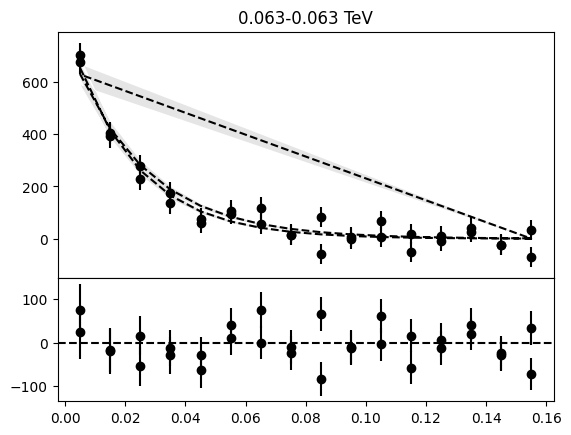

In [25]:
flux_ratios = calculate_UL_merged(cts_40deg, cts_err_40deg, psf_hbu_40deg, cts_20deg, cts_err_20deg, psf_hbu_20deg)

In [26]:
for i, flux_ratio in enumerate(flux_ratios):
    plt.errorbar(e*(0.95*1.03**i), flux_ratio,flux_ratio/3, alpha=0.2+0.2*i, uplims=True, linestyle='none',marker='o', label="40deg - "+str(round(sigmas_ext[i],3))+r'$^\circ$',color='black')
plt.xscale("log")
plt.yscale("log")
plt.ylabel(r"$F_{ext}/F_{ps}$")
plt.xlabel("E [TeV]")
plt.xlim(0.04,11)
plt.legend()

NameError: name 'flux_ratios' is not defined

In [ ]:
def calculate_UL_merged(cts_40deg, cts_err_40deg, psf_hbu_40deg, cts_20deg, cts_err_20deg, psf_hbu_20deg):
    flux_ratios = np.zeros((len(sigmas_ext), len(e)))
    
    for i, ((ct_40deg, ct_err_40deg), (ct_20deg, ct_err_20deg)) in enumerate(zip(zip(cts_40deg, cts_err_40deg), zip(cts_20deg, cts_err_20deg))):
        # psf_index will store the best index for accessing the PSF values form the file.
        psf_index = np.argmin(np.abs(psf_e_means - e[i]))
        sigma_1_40deg, sigma_2_40deg, sigma_3_40deg, scale_40deg, ampl_2_40deg, ampl_3_40deg = psf_hbu_40deg.data[psf_index][0]
        sigma_1_20deg, sigma_2_20deg, sigma_3_20deg, scale_20deg, ampl_2_20deg, ampl_3_20deg = psf_hbu_20deg.data[psf_index][0]
        
        # Normalization of the PSF model to fit best the blazar
            def psf_model_40deg(th2):
                gauss1 = np.exp(-th2 / (2 * sigma_1_40deg**2))
                gauss2 = ampl_2_40deg * np.exp(-th2 / (2 * sigma_2_40deg**2))
                gauss3 = ampl_3_40deg * np.exp(-th2 / (2 * sigma_3_40deg**2))
                return (gauss1 + gauss2 + gauss3)
            
            def psf_model_20deg(th2):
                gauss1 = np.exp(-th2 / (2 * sigma_1_20deg**2))
                gauss2 = ampl_2_20deg * np.exp(-th2 / (2 * sigma_2_20deg**2))
                gauss3 = ampl_3_20deg * np.exp(-th2 / (2 * sigma_3_20deg**2))
                return (gauss1 + gauss2 + gauss3)

        # rescaling the psf component to match total counts of the data
        psf_component_40deg = psf_model_40deg(th2)
        psf_component_40deg = sum(ct_40deg)*psf_component_40deg/sum(psf_component_40deg)
        psf_component_err_40deg = np.sqrt(sum(ct_err_40deg**2))*psf_component_40deg/sum(psf_component_40deg)

        psf_component_20deg = psf_model_20deg(th2)
        psf_component_20deg = sum(ct_20deg) * psf_component_20deg / sum(psf_component_20deg)
        psf_component_err_20deg = np.sqrt(sum(ct_err_20deg**2)) * psf_component_20deg / sum(psf_component_20deg)

        # 40 DEG psf fitting
        step = 1.01
        chi2_noext_best_40deg = 1e10
        adjust_40deg = 1

        chi2_noext_40deg = np.sum(((ct_40deg - psf_component_40deg)**2 /  (ct_err_40deg**2 + psf_component_err_40deg**2)))
        
        while chi2_noext_40deg < chi2_noext_best_40deg:
            chi2_noext_best_40deg = chi2_noext_40deg

            chisq0 = np.sum((ct_40deg - step * adjust_40deg * psf_component_40deg)**2 / (ct_err_40deg**2 + (step * adjust_40deg * psf_component_err_40deg)**2))
            chisq1 = np.sum((ct_40deg - adjust_40deg * psf_component_40deg / step)**2 /  (ct_err_40deg**2 + (adjust_40deg * psf_component_err_40deg / step)**2))
            chisq_vec = np.array([chisq0, chisq1])
            chi2_noext_40deg = min(chisq_vec)
            ind = np.argmin(chisq_vec)
            
            if chi2_noext_40deg < chi2_noext_best_40deg:
                if ind == 0:
                    adjust_40deg *= step
                if ind == 1:
                    adjust_40deg /= step
        
        psf_component_40deg *= adjust_40deg
        psf_component_err_40deg *= adjust_40deg
        chi2_noext_40deg = np.sum(((ct_40deg - psf_component_40deg)**2 / (ct_err_40deg**2 + psf_component_err_40deg**2)))

        # 20 DEG psf fitting
        chi2_noext_best_20deg = 1e10
        adjust_20deg = 1
        chi2_noext_20deg = np.sum(((ct_20deg - psf_component_20deg)**2 / (ct_err_20deg**2 + psf_component_err_20deg**2)))
        
        while chi2_noext_20deg < chi2_noext_best_20deg:
            chi2_noext_best_20deg = chi2_noext_20deg
            
            chisq0 = np.sum((ct_20deg - step * adjust_20deg * psf_component_20deg)**2 / (ct_err_20deg**2 + (step * adjust_20deg * psf_component_err_20deg)**2))
            chisq1 = np.sum((ct_20deg - adjust_20deg * psf_component_20deg / step)**2 / (ct_err_20deg**2 + (adjust_20deg * psf_component_err_20deg / step)**2))
            
            chisq_vec = np.array([chisq0, chisq1])
            chi2_noext_20deg = min(chisq_vec)
            ind = np.argmin(chisq_vec)
            
            if chi2_noext_20deg < chi2_noext_best_20deg:
                if ind == 0:
                    adjust_20deg *= step
                if ind == 1:
                    adjust_20deg /= step
        
        psf_component_20deg *= adjust_20deg
        psf_component_err_20deg *= adjust_20deg
        chi2_noext_20deg = np.sum(((ct_20deg - psf_component_20deg)**2 /(ct_err_20deg**2 + psf_component_err_20deg**2)))

        # Wrap up
        ct = np.concatenate([ct_40deg, ct_20deg])
        ct_err = np.concatenate([ct_err_40deg, ct_err_20deg])
        psf_component = np.concatenate([psf_component_40deg, psf_component_20deg])
        psf_component_err = np.concatenate([psf_component_err_40deg, psf_component_err_20deg])
        chi2_noext = np.sum(((ct - psf_component)**2 /(ct_err**2 + psf_component_err**2)))
        
        fig, axs = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [2, 1]})
        fig.subplots_adjust(hspace=0)
        axs[0].errorbar(th2,ct,ct_err,linestyle='none',marker='o',label=name,color='black')
        axs[0].plot(th2,psf_component,color='black',linestyle='dashed',label='PSF')
        axs[0].fill_between(th2,(psf_component-psf_component_err),(psf_component+psf_component_err),color='black',alpha=0.1,linewidth=0)
        axs[0].set_title(str(round(e[i],3))+'-'+str(round(e[i],3))+r' TeV')
        axs[1].errorbar(th2,ct - psf_component,np.sqrt(ct_err**2+psf_component_err**2),marker='o',linestyle='none',color='black')
        axs[1].axhline(0,color='black',linestyle='dashed')
    
        # For each sigma_ext: add a gaussian term norm_ext*gauss(sigma_ext) convolved with the psf, to the point source model (psf only), until delta_chi2 is > 2.71.
        # With this you found norm_ext such that the fit breaks. Lets call this norm_ext_br
        # Then the upper limit to the detectable ext. emission should be given by an extended emission of the form of: norm_ext_br*gauss(sigma_ext).
        for k, sigma_ext in enumerate(sigmas_ext):
            def ext_model_40deg(th2):
                sigma1_conv = np.sqrt(sigma_1_40deg**2 + sigma_ext**2)
                sigma2_conv = np.sqrt(sigma_2_40deg**2 + sigma_ext**2)
                sigma3_conv = np.sqrt(sigma_3_40deg**2 + sigma_ext**2)
                gauss1_conv = np.exp(-th2 / (2 * sigma1_conv**2))
                gauss2_conv = ampl_2_40deg * np.exp(-th2 / (2 * sigma2_conv**2))
                gauss3_conv = ampl_3_40deg * np.exp(-th2 / (2 * sigma3_conv**2))
                return gauss1_conv + gauss2_conv + gauss3_conv
                
            ct_ext_40deg = ext_model_40deg(th2)
            ct_ext_40deg = sum(ct_40deg) * ct_ext_40deg / sum(ct_ext_40deg)
            ct_ext_plus_src_40deg = ct_ext_40deg + psf_component_40deg
            chi2_ext_40deg = np.sum(((ct_40deg - ct_ext_40deg - psf_component_40deg)**2 / (ct_err_40deg**2 + psf_component_err_40deg**2)))
            
            step = 1.01
            chi2_ext_best_40deg = 1e10
            adjust_ext_40deg = 1
            adjust_point_40deg = 1
            while chi2_ext_40deg < chi2_ext_best_40deg:
                chi2_ext_best_40deg = chi2_ext_40deg
                
                chisq0 = np.sum((ct_40deg - step * adjust_point_40deg * psf_component_40deg - adjust_ext_40deg * ct_ext_40deg)**2 / (ct_err_40deg**2 + (step * adjust_point_40deg * psf_component_err_40deg)**2))
                chisq1 = np.sum((ct_40deg - adjust_point_40deg * psf_component_40deg / step - adjust_ext_40deg * ct_ext_40deg)**2 / (ct_err_40deg**2 + (adjust_point_40deg * psf_component_err_40deg / step)**2))
                chisq2 = np.sum((ct_40deg - adjust_point_40deg * psf_component_40deg - step * adjust_ext_40deg * ct_ext_40deg)**2 / (ct_err_40deg**2 + adjust_point_40deg**2 * psf_component_err_40deg**2))
                chisq3 = np.sum((ct_40deg - adjust_point_40deg * psf_component_40deg - adjust_ext_40deg * ct_ext_40deg / step)**2 / (ct_err_40deg**2 + adjust_point_40deg**2 * psf_component_err_40deg**2))
                
                chisq_vec = np.array([chisq0, chisq1, chisq2, chisq3])
                chi2_ext_40deg = min(chisq_vec)
                ind = np.argmin(chisq_vec)
                
                if chi2_ext_40deg < chi2_ext_best_40deg:
                    if ind == 0:
                        adjust_point_40deg *= step
                    if ind == 1:
                        adjust_point_40deg /= step
                    if ind == 2:
                        adjust_ext_40deg *= step
                    if ind == 3:
                        adjust_ext_40deg /= step
            
            ct_ext_40deg *= adjust_ext_40deg
            psf_component_40deg *= adjust_point_40deg
            psf_component_err_40deg *= adjust_point_40deg

            chi2_ext_final_40deg = np.sum(((ct_40deg - ct_ext_40deg - psf_component_40deg)**2 / (ct_err_40deg**2 + psf_component_err_40deg**2)))

            def ext_model_20deg(th2):
                sigma1_conv = np.sqrt(sigma_1_20deg**2 + sigma_ext**2)
                sigma2_conv = np.sqrt(sigma_2_20deg**2 + sigma_ext**2)
                sigma3_conv = np.sqrt(sigma_3_20deg**2 + sigma_ext**2)
                gauss1_conv = np.exp(-th2 / (2 * sigma1_conv**2))
                gauss2_conv = ampl_2_20deg * np.exp(-th2 / (2 * sigma2_conv**2))
                gauss3_conv = ampl_3_20deg * np.exp(-th2 / (2 * sigma3_conv**2))
                return gauss1_conv + gauss2_conv + gauss3_conv

            ct_ext_20deg = ext_model_20deg(th2)
            ct_ext_20deg = sum(ct_20deg) * ct_ext_20deg / sum(ct_ext_20deg)
            ct_ext_plus_src_20deg = ct_ext_20deg + psf_component_20deg
            chi2_ext_20deg = np.sum(((ct_20deg - ct_ext_20deg - psf_component_20deg)**2 / (ct_err_20deg**2 + psf_component_err_20deg**2)))
            
            adjust_ext_20deg = 1
            adjust_point_20deg = 1
            chi2_ext_best_20deg = 1e10
            
            while chi2_ext_20deg < chi2_ext_best_20deg:
                chi2_ext_best_20deg = chi2_ext_20deg
                chisq0 = np.sum((ct_20deg - step * adjust_point_20deg * psf_component_20deg - adjust_ext_20deg * ct_ext_20deg)**2 / (ct_err_20deg**2 + (step * adjust_point_20deg * psf_component_err_20deg)**2))
                chisq1 = np.sum((ct_20deg - adjust_point_20deg * psf_component_20deg / step - adjust_ext_20deg * ct_ext_20deg)**2 / (ct_err_20deg**2 + (adjust_point_20deg * psf_component_err_20deg / step)**2))
                chisq2 = np.sum((ct_20deg - adjust_point_20deg * psf_component_20deg - step * adjust_ext_20deg * ct_ext_20deg)**2 / (ct_err_20deg**2 + adjust_point_20deg**2 * psf_component_err_20deg**2))
                chisq3 = np.sum((ct_20deg - adjust_point_20deg * psf_component_20deg - adjust_ext_20deg * ct_ext_20deg / step)**2 / (ct_err_20deg**2 + adjust_point_20deg**2 * psf_component_err_20deg**2))
                
                chisq_vec = np.array([chisq0, chisq1, chisq2, chisq3])
                chi2_ext_20deg = min(chisq_vec)
                ind = np.argmin(chisq_vec)
                
                if chi2_ext_20deg < chi2_ext_best_20deg:
                    if ind == 0:
                        adjust_point_20deg *= step
                    if ind == 1:
                        adjust_point_20deg /= step
                    if ind == 2:
                        adjust_ext_20deg *= step
                    if ind == 3:
                        adjust_ext_20deg /= step
            
            ct_ext_20deg *= adjust_ext_20deg
            psf_component_20deg *= adjust_point_20deg
            psf_component_err_20deg *= adjust_point_20deg
            
            chi2_ext_final_20deg = np.sum(((ct_20deg - ct_ext_20deg - psf_component_20deg)**2 / (ct_err_20deg**2 + psf_component_err_20deg**2)))

            # wrap up
            ct_ext = np.concatenate([ct_ext_40deg, ct_ext_20deg])
            psf_component = np.concatenate([psf_component_40deg, psf_component_20deg])
            psf_component_err = np.concatenate([psf_component_err_40deg, psf_component_err_20deg])
            chi2_ext = np.sum(((ct - psf_component - ct_ext)**2 /(ct_err**2 + psf_component_err**2)))
            
            chi2_ext_best = chi2_ext
            ct_ext_best = ct_ext
            print(f"Best fit extended plus point gives chi2: {chi2_ext}")

            # Upper limits
            step=1.01
            chi2_ext_best = chi2_ext
            adjust_ext = 1
            adjust_point = 1
            while(chi2_ext < chi2_ext_best + 2.71):
                adjust_ext *= step
                ct_ext = ct_ext_best*adjust_ext
                chi2_ext = np.sum(((ct - psf_component - ct_ext)**2 / (ct_err**2 + psf_component_err**2)))

                chi2_ext_best_fixed_ext = 1e10
                while(chi2_ext < chi2_ext_best_fixed_ext):
                    chi2_ext_best_fixed_ext = chi2_ext
                    
                    chisq0=sum((ct-step*adjust_point*psf_component-ct_ext)**2/(ct_err**2+(step*adjust_point*psf_component_err)**2))
                    chisq1=sum((ct-adjust_point*psf_component/step-ct_ext)**2/(ct_err**2+(adjust_point*psf_component_err/step)**2))
                    chisq_vec=np.array([chisq0,chisq1])
                    chi2_ext=min(chisq_vec)
                    ind=np.argmin(chisq_vec)
                    
                    if(chi2_ext<chi2_ext_best_fixed_ext):
                        if(ind==0):
                            adjust_point*=step
                        if(ind==1):
                            adjust_point/=step

            flux_ratio = np.sum(ct_ext)/cts_tot_best
            flux_ratios[k][i] = flux_ratio
            axs[0].plot(th2,ct_ext,color='blue',alpha=0.5,linestyle='dashdot',label='extended source U.L.')
            
        plt.xlabel(r'$\theta^2$, deg$^2$')
        axs[0].set_ylabel('Counts')
        axs[0].legend()
        axs[0].set_yscale('log')
        plt.show()
    return flux_ratios